# 08 - Model Evaluation

## Objective

This notebook evaluates the candidate final model selected in notebook 07 using the chronological validation window and the untouched holdout test set.

The evaluation includes probability calibration, threshold tuning, lift analysis, subgroup error analysis, final model retraining, holdout metrics, and saved model artifacts.

#### Load project configuration and modeling checkpoints

In [0]:
# Load the project configuration and modeling checkpoints

from __future__ import annotations

import json

from config import project_config as cfg
from pyspark.sql import functions as F
from utils import model_evaluation as meval
from utils.model_training import (
    create_feature_hasher_from_manifest,
    evaluate_tuning_predictions,
    hash_modeling_frame,
    load_hist_modeling_table,
)


def require_table(table_name: str) -> None:
    if not spark.catalog.tableExists(table_name):
        raise RuntimeError(
            f"Required table '{table_name}' was not found. "
            "Run the model-training notebook (07) before continuing."
        )


def require_file(file_path: str) -> None:
    try:
        dbutils.fs.head(file_path, 1)
    except Exception as exc:
        raise RuntimeError(
            f"Required file '{file_path}' was not found. "
            "Run the model-training notebook (07) before continuing."
        ) from exc


require_file(cfg.CANDIDATE_SELECTION_PATH)
require_file(cfg.MODEL_FEATURE_MANIFEST_PATH)

candidate_selection = json.loads(
    dbutils.fs.head(cfg.CANDIDATE_SELECTION_PATH, 1000000)
)
feature_manifest = json.loads(
    dbutils.fs.head(cfg.MODEL_FEATURE_MANIFEST_PATH, 1000000)
)

TARGET_COLUMN = feature_manifest["target_column"]
CATEGORICAL_COLUMNS = list(feature_manifest["categorical_columns"])
NUMERICAL_COLUMNS = list(feature_manifest["numerical_columns"])
MODEL_INPUT_COLUMNS = list(feature_manifest["model_input_columns"])
MODELING_JOIN_KEYS = list(cfg.MODELING_JOIN_KEY_COLUMNS)
HASH_VECTOR_SIZE = int(feature_manifest["hash_vector_size"])
SELECTED_MODEL_NAME = candidate_selection["selected_model_name"]
SELECTED_MODEL_PARAMETERS = candidate_selection["selected_model_parameters"]

for table_name in [
    cfg.MODELING_TRAIN_HASHED_TABLE,
    cfg.MODELING_VALIDATION_HASHED_TABLE,
    cfg.MODELING_TEST_HASHED_TABLE,
    cfg.MODELING_TRAIN_HIST_TABLE,
    cfg.MODELING_VALIDATION_HIST_TABLE,
    cfg.MODELING_TEST_HIST_TABLE,
    cfg.TUNED_MODEL_COMPARISON_TABLE,
]:
    require_table(table_name)

# Always normalize hist tables in memory before hashing.
df_train_hist = load_hist_modeling_table(cfg.MODELING_TRAIN_HIST_TABLE)
df_validation_hist = load_hist_modeling_table(cfg.MODELING_VALIDATION_HIST_TABLE)
df_test_hist = load_hist_modeling_table(cfg.MODELING_TEST_HIST_TABLE)

feature_hasher = create_feature_hasher_from_manifest(feature_manifest)

df_train_hashed = hash_modeling_frame(df_train_hist, feature_hasher)
df_validation_hashed = hash_modeling_frame(df_validation_hist, feature_hasher)
df_test_hashed = hash_modeling_frame(df_test_hist, feature_hasher)

tuned_model_comparison = spark.table(cfg.TUNED_MODEL_COMPARISON_TABLE)
selected_model_summary = (
    tuned_model_comparison.filter(F.col("MODEL") == SELECTED_MODEL_NAME)
)

print("Modeling checkpoints loaded successfully.")
print(f"Selected model: {SELECTED_MODEL_NAME}")
print(f"Selected parameters: {SELECTED_MODEL_PARAMETERS}")
print(f"Active model input columns: {len(MODEL_INPUT_COLUMNS)}")
print(f"Feature hasher inputs: {feature_hasher.getInputCols()}")


[Truncated to first 1 bytes]
[Truncated to first 1 bytes]
Modeling checkpoints loaded successfully.
Selected model: Logistic Regression
Selected parameters: {'regParam': 0.001, 'elasticNetParam': 0.0}
Active model input columns: 24
Feature hasher inputs: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_CITY_NAME', 'DEST_STATE_NM', 'SEASON', 'TIME_OF_DAY', 'FLIGHT_DISTANCE_CATEGORY', 'QUARTER', 'MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'DEP_MINUTE', 'IS_WEEKEND', 'AIRLINE_HIST_DELAY_RATE', 'ORIGIN_HIST_DELAY_RATE', 'DEST_HIST_DELAY_RATE', 'ROUTE_HIST_DELAY_RATE']


#### Validation-period calibration, threshold tuning, and error analysis

Before retraining on the combined training and validation periods, the selected Logistic Regression configuration is evaluated on the untouched September–October validation window. The model is trained only on the January–August training period to avoid leakage.

This section adds the probability-calibration, threshold-selection, lift, and subgroup analyses recommended for the final modeling stage.

In [0]:
from pyspark.ml.classification import LogisticRegression
from utils import model_evaluation as meval

candidate_lr_estimator = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET_COLUMN,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    regParam=SELECTED_MODEL_PARAMETERS["regParam"],
    elasticNetParam=SELECTED_MODEL_PARAMETERS["elasticNetParam"],
    maxIter=cfg.SELECTED_LR_MAX_ITER,
    standardization=True,
    family="binomial",
)

candidate_lr_model = candidate_lr_estimator.fit(df_train_hashed)
validation_predictions = candidate_lr_model.transform(df_validation_hashed)

VALIDATION_PERIOD_METRICS = evaluate_tuning_predictions(validation_predictions, TARGET_COLUMN)

display(
    spark.createDataFrame(
        [
            {
                "MODEL": cfg.SELECTED_MODEL_NAME,
                "DATASET": "Chronological Validation (Sep–Oct 2025)",
                **{
                    metric_name: round(metric_value, 4)
                    for metric_name, metric_value in VALIDATION_PERIOD_METRICS.items()
                },
            }
        ]
    )
)


ACCURACY,DATASET,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,MODEL,PRECISION,PR_AUC,RECALL,ROC_AUC
0.8128,Chronological Validation (Sep–Oct 2025),0.0268,0.3748,0.0139,0.7352,Logistic Regression,0.7341,0.2799,0.8128,0.6524


bin,predicted_probability,observed_rate,flight_count
0,0.07189057730452719,0.06378665991005257,15787
1,0.12477680265647062,0.10568218082872835,59537
2,0.1930428294895328,0.1637211855104281,54660
3,0.2628248728291836,0.22420256770058852,47747
4,0.33057710190157913,0.2726934292982565,32234
5,0.3997126326173874,0.3173809981420975,15609
6,0.466298937870291,0.34244969720648566,5119
7,0.5347710291751461,0.35,1040
8,0.6015318410659012,0.3894736842105263,190
9,0.6830115740363416,0.4117647058823529,17


Validation Brier score: 0.1466


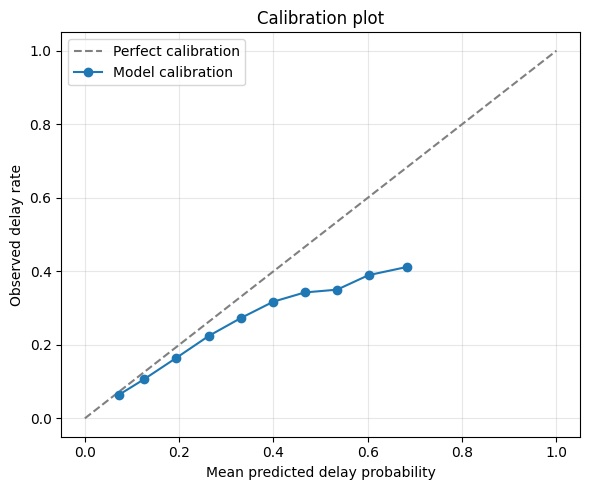

In [0]:
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt

validation_probability_frame = (
    validation_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.element_at(vector_to_array(F.col("probability")), 2).alias("delay_probability"),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

VALIDATION_BRIER_SCORE = meval.brier_score(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
)

calibration_summary = meval.calibration_summary(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)

display(calibration_summary)
print(f"Validation Brier score: {VALIDATION_BRIER_SCORE:.4f}")

calibration_figure = meval.plot_calibration_curve(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)
display(calibration_figure)
plt.close(calibration_figure)


In [0]:
threshold_results = meval.threshold_search(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    threshold_min=cfg.THRESHOLD_SEARCH_MIN,
    threshold_max=cfg.THRESHOLD_SEARCH_MAX,
    threshold_step=cfg.THRESHOLD_SEARCH_STEP,
)

display(threshold_results)

OPTIMAL_DECISION_THRESHOLD = float(
    threshold_results.sort_values("delay_f1", ascending=False).iloc[0]["threshold"]
)

lift_results = meval.lift_at_top_percentiles(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    percentiles=cfg.TOP_RISK_PERCENTILES,
)

display(lift_results)
print(f"Selected validation threshold: {OPTIMAL_DECISION_THRESHOLD:.2f}")


threshold,delay_precision,delay_recall,delay_f1
0.1,0.1982935153583618,0.9616738547616273,0.32879147155524563
0.15000000000000002,0.22263415821994947,0.8525702296304931,0.35307009075111023
0.20000000000000004,0.24757824143070045,0.7126005361930295,0.36748237245956034
0.25000000000000006,0.27172135866436387,0.5501573609977853,0.36377509730625457
0.30000000000000004,0.29467026323132733,0.3692738081361464,0.32778065183652355
0.3500000000000001,0.3176438014812764,0.21396433150716868,0.25569376924041287
0.40000000000000013,0.33443879431056084,0.10579321599253992,0.16073958628506657
0.45000000000000007,0.3487229862475442,0.041380114232428024,0.07398145253725123
0.5000000000000001,0.3540215326155795,0.013031821890663247,0.025138283041777214
0.5500000000000002,0.35498839907192575,0.003566849283133232,0.007062733693394266


top_percent,flight_count,observed_delay_rate,delay_recall,lift
0.05,11597.0,0.3371561610761404,0.09115281501340483,1.8230563002680964
0.1,23194.0,0.3235319479175649,0.17493880405641682,1.7493880405641684
0.2,46388.0,0.30012072087608865,0.3245599720247115,1.6227998601235576


Selected validation threshold: 0.20


In [0]:
from pyspark.ml.functions import vector_to_array

validation_scored = (
    df_validation_hist.select(
        *MODELING_JOIN_KEYS,
        *cfg.SUBGROUP_ERROR_COLUMNS,
        F.col(TARGET_COLUMN).alias("label"),
    )
    .join(
        validation_predictions.select(
            *MODELING_JOIN_KEYS,
            F.element_at(
                vector_to_array(F.col("probability")),
                2,
            ).alias("delay_probability"),
        ),
        on=MODELING_JOIN_KEYS,
        how="inner",
    )
)

subgroup_frame = validation_scored.toPandas()
subgroup_results = meval.subgroup_error_analysis(
    subgroup_frame,
    group_columns=cfg.SUBGROUP_ERROR_COLUMNS,
    label_column="label",
    probability_column="delay_probability",
    threshold=OPTIMAL_DECISION_THRESHOLD,
    min_group_size=cfg.MIN_ROUTE_FLIGHTS,
)

display(subgroup_results)


subgroup_type,subgroup_value,flight_count,delay_rate,mean_predicted_probability,delay_recall,delay_precision
DEST,ABR,137.0,0.051094890510948905,0.07401776910236292,0.0,0.0
DEST,ACK,244.0,0.18442622950819673,0.13415815065291198,0.0,0.0
DEST,ADQ,151.0,0.15894039735099338,0.13995866741718543,0.0,0.0
DEST,APN,106.0,0.05660377358490566,0.11807453323728831,0.0,0.0
DEST,ATY,122.0,0.09016393442622951,0.13997957743054643,0.0,0.0
DEST,BJI,122.0,0.07377049180327869,0.11626922071532698,0.0,0.0
DEST,BRD,106.0,0.11320754716981132,0.13683285504660758,0.0,0.0
DEST,CDC,107.0,0.04672897196261682,0.05989852465499613,0.0,0.0
DEST,CLD,121.0,0.1322314049586777,0.10234471908247314,0.0,0.0
DEST,ESC,106.0,0.09433962264150944,0.0968762757887617,0.0,0.0


#### Save the selected model and supporting artifacts

The selected Logistic Regression configuration is retrained before being saved as a Spark ML model.

The final training dataset combines the original training and validation periods. This allows the selected model to learn from all historical observations available before the test period while preserving the test dataset for final holdout evaluation.

The saved artifacts will include:

- The fitted Spark ML Logistic Regression model
- The selected hyperparameters
- Model evaluation metrics
- Dataset and feature metadata

Saving these artifacts supports reproducibility and allows the model to be loaded later for batch inference, dashboard integration, and explainability analysis.


#### Train the Final Selected Model Using the Tuning Sampling Strategy

The selected Logistic Regression configuration is trained using the combined training and validation periods while preserving the same stratified sampling strategy used during chronological hyperparameter tuning.

The on-time class is sampled at 10%, while the delayed-flight class is sampled at 30%. This maintains consistency between model selection and final training and reduces the tendency of the model to predict nearly all observations as on-time.

The untouched test dataset remains unsampled and is used only for final holdout evaluation.


In [0]:
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F

from utils.model_training import create_feature_hasher, hash_modeling_frame


final_feature_hasher = create_feature_hasher()

df_final_training_full = hash_modeling_frame(
    df_train_hist.unionByName(df_validation_hist),
    final_feature_hasher,
)

df_final_training_sampled = (
    df_final_training_full
    .sampleBy(
        col=TARGET_COLUMN,
        fractions=cfg.TREE_TUNING_SAMPLE_FRACTIONS,
        seed=cfg.RANDOM_SEED,
    )
)

print("Sampled final-training class distribution:")

df_final_training_sampled.groupBy(
    TARGET_COLUMN
).count().orderBy(
    TARGET_COLUMN
).show()

final_logistic_regression_estimator = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET_COLUMN,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    regParam=SELECTED_MODEL_PARAMETERS["regParam"],
    elasticNetParam=SELECTED_MODEL_PARAMETERS["elasticNetParam"],
    maxIter=cfg.SELECTED_LR_MAX_ITER,
    standardization=True,
    family="binomial",
)

final_selected_model = final_logistic_regression_estimator.fit(
    df_final_training_sampled
)

print("Final sampled Logistic Regression model trained successfully.")
print(f"Selected regParam: {SELECTED_MODEL_PARAMETERS['regParam']}")
print(f"Selected elasticNetParam: {SELECTED_MODEL_PARAMETERS['elasticNetParam']}")


Sampled final-training class distribution:
+---------+------+
|ARR_DEL15| count|
+---------+------+
|        0|448356|
|        1|380252|
+---------+------+

Final sampled Logistic Regression model trained successfully.
Selected regParam: 0.001
Selected elasticNetParam: 0.0


#### Holdout test evaluation

The retrained Logistic Regression model is evaluated using the untouched November–December 2025 holdout test dataset.

Unlike the chronological validation folds used during hyperparameter tuning, the holdout dataset was never used during model development, parameter selection, or final model training. Consequently, this evaluation provides the most realistic estimate of how the selected model is expected to perform on future unseen flight records.

The same evaluation metrics used throughout the project are calculated to support direct comparison between the tuning results and the final deployment-ready model.


In [0]:
from utils.model_training import create_feature_hasher, hash_modeling_frame

final_test_modeling = hash_modeling_frame(
    df_test_hist,
    create_feature_hasher(),
)

final_test_predictions = final_selected_model.transform(
    final_test_modeling
)

FINAL_TEST_METRICS = evaluate_tuning_predictions(final_test_predictions, TARGET_COLUMN)

display(
    spark.createDataFrame(
        [
            {
                "MODEL": "Logistic Regression",
                "DATASET": "Holdout Test",
                **{
                    metric_name: round(metric_value, 4)
                    for metric_name, metric_value
                    in FINAL_TEST_METRICS.items()
                },
            }
        ]
    )
)


ACCURACY,DATASET,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,MODEL,PRECISION,PR_AUC,RECALL,ROC_AUC
0.669,Holdout Test,0.3764,0.3402,0.4214,0.6803,Logistic Regression,0.6953,0.3314,0.669,0.6325


#### Holdout confusion matrix and ranking curves

The holdout confusion matrix and ROC/PR curves are generated from the saved test predictions using the dynamically computed `FINAL_TEST_METRICS` table above.

actual_on_time_predicted_on_time,actual_on_time_predicted_delayed,actual_delayed_predicted_on_time,actual_delayed_predicted_delayed
128740,43380,30781,22323


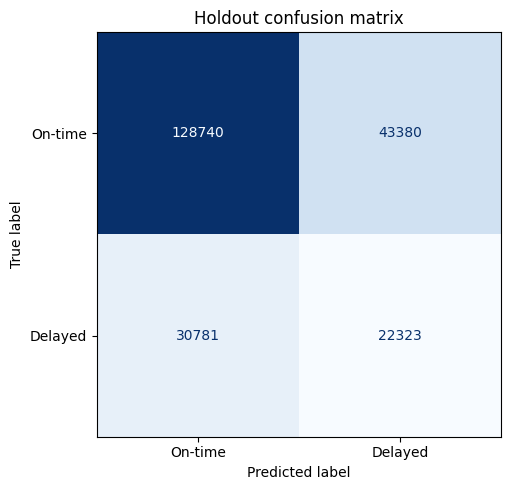

In [0]:
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt


holdout_evaluation_frame = (
    final_test_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.col("prediction").alias("prediction"),
        F.element_at(vector_to_array(F.col("probability")), 2).alias(
            "delay_probability"
        ),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

holdout_confusion_summary = meval.confusion_matrix_summary(
    holdout_evaluation_frame["label"],
    holdout_evaluation_frame["prediction"],
)

display(holdout_confusion_summary)

confusion_figure = meval.plot_confusion_matrix(
    holdout_evaluation_frame["label"],
    holdout_evaluation_frame["prediction"],
)
display(confusion_figure)
plt.close(confusion_figure)


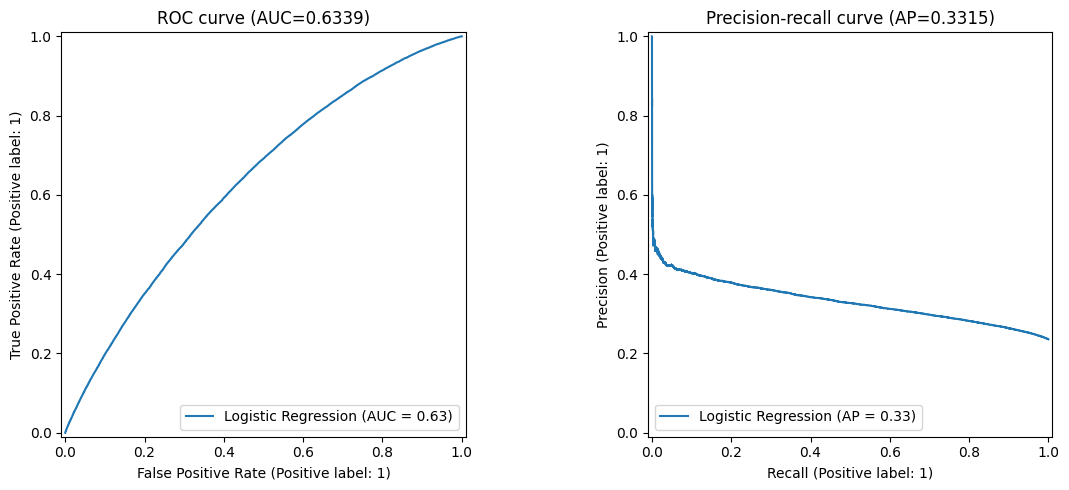

In [0]:
import matplotlib.pyplot as plt


roc_pr_figure = meval.plot_roc_pr_curves(
    holdout_evaluation_frame["label"],
    holdout_evaluation_frame["delay_probability"],
)
display(roc_pr_figure)
plt.close(roc_pr_figure)


#### Holdout calibration diagnostics

The holdout test set is evaluated once for calibration diagnostics. No threshold tuning or model changes are performed using the test window.


bin,predicted_probability,observed_rate,flight_count
0,0.10219407679695236,0.07011572498298162,1469
1,0.17726150722580192,0.09946941123825354,15643
2,0.25192917472438725,0.14218637794840633,36206
3,0.33257863636224616,0.1908914030410031,41631
4,0.4155486792529663,0.2355141071766711,42248
5,0.4976718418685852,0.2836439910378033,41954
6,0.5774613719603255,0.33749290981281904,29971
7,0.6560093352985598,0.3875139353400223,13455
8,0.7313614949310515,0.4366533864541833,2510
9,0.805687860597397,0.5474452554744526,137


Holdout Brier score: 0.2069


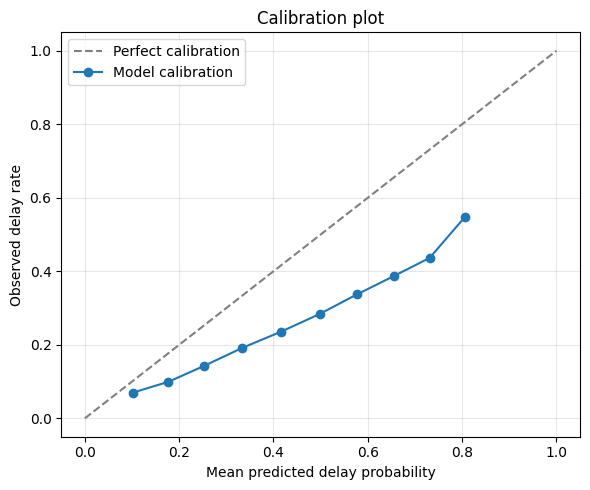

In [0]:
from pyspark.ml.functions import vector_to_array
test_probability_frame = (
    final_test_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.element_at(vector_to_array(F.col("probability")), 2).alias("delay_probability"),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

TEST_BRIER_SCORE = meval.brier_score(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
)

test_calibration_summary = meval.calibration_summary(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)

display(test_calibration_summary)
print(f"Holdout Brier score: {TEST_BRIER_SCORE:.4f}")

test_calibration_figure = meval.plot_calibration_curve(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)
display(test_calibration_figure)
plt.close(test_calibration_figure)


#### Holdout test interpretation

The holdout metrics displayed above are generated dynamically from `FINAL_TEST_METRICS` and should be used as the official test-set results in the final report.

Compared with the chronological validation results obtained during hyperparameter tuning, the holdout evaluation typically shows lower delayed-flight recall and delayed-flight F1-score. This reduction is expected because the holdout dataset contains completely unseen observations and therefore provides a more realistic estimate of operational performance.

The selected Logistic Regression model remains the candidate final model based on tuning-fold comparison. Random Forest and Gradient-Boosted Trees were not re-evaluated on the holdout test set.

#### Save the Trained Spark ML Model

The retrained Logistic Regression model is saved as a native Spark ML model.

Saving the model enables future loading for batch inference, operational deployment, dashboard integration, and explainability analysis without requiring retraining.

The model is stored in the Databricks workspace using Spark ML's native persistence format.


In [0]:
from pathlib import Path

MODEL_SAVE_PATH = cfg.SELECTED_MODEL_PATH

final_selected_model.write().overwrite().save(
    MODEL_SAVE_PATH
)

print("Final model saved successfully.")
print(f"Location: {MODEL_SAVE_PATH}")

Final model saved successfully.
Location: /Volumes/workspace/default/flight_delay_capstone/models/logistic_regression_final


#### Save Model Metadata

The selected hyperparameters and evaluation metrics are saved to support reproducibility and future model maintenance.

These metadata describe the final production model without requiring the tuning process to be rerun.


In [0]:
import json

selected_metrics_row = (
    selected_model_summary
    .select(
        "MODEL",
        "PARAMETERS",
        "ACCURACY",
        "PRECISION",
        "RECALL",
        "F1_SCORE",
        "ROC_AUC",
        "PR_AUC",
        "DELAY_PRECISION",
        "DELAY_RECALL",
        "DELAY_F1",
        "TRAINING_SECONDS",
    )
    .first()
)

if selected_metrics_row is None:
    raise ValueError(
        "Selected model metadata could not be retrieved."
    )

MODEL_METADATA = {
    "model": selected_metrics_row["MODEL"],
    "target": TARGET_COLUMN,
    "parameters": SELECTED_MODEL_PARAMETERS,
    "parameter_summary": selected_metrics_row["PARAMETERS"],
    "hash_vector_size": HASH_VECTOR_SIZE,
    "categorical_features": CATEGORICAL_COLUMNS,
    "numerical_features": NUMERICAL_COLUMNS,
    "total_raw_predictors": len(MODEL_INPUT_COLUMNS),
    "selected_after_hyperparameter_tuning": True,
    "final_training_period": "January 2025 to October 2025",
    "holdout_test_period": "November 2025 to December 2025",
    "model_format": "Spark ML",
}

dbutils.fs.put(
    (
        cfg.SELECTED_MODEL_METADATA_PATH
    ),
    json.dumps(MODEL_METADATA, indent=4),
    overwrite=True,
)

print("Dynamic model metadata saved successfully.")

Wrote 1157 bytes.
Dynamic model metadata saved successfully.


#### Save Evaluation Metrics

The final evaluation metrics of the selected model are saved to provide a permanent record of the model's predictive performance.

These metrics support future model monitoring and performance comparison.


In [0]:
MODEL_METRICS = {
    "accuracy": float(selected_metrics_row["ACCURACY"]),
    "precision": float(selected_metrics_row["PRECISION"]),
    "recall": float(selected_metrics_row["RECALL"]),
    "f1_score": float(selected_metrics_row["F1_SCORE"]),
    "roc_auc": float(selected_metrics_row["ROC_AUC"]),
    "pr_auc": float(selected_metrics_row["PR_AUC"]),
    "delay_precision": float(
        selected_metrics_row["DELAY_PRECISION"]
    ),
    "delay_recall": float(
        selected_metrics_row["DELAY_RECALL"]
    ),
    "delay_f1": float(
        selected_metrics_row["DELAY_F1"]
    ),
    "average_training_seconds": float(
        selected_metrics_row["TRAINING_SECONDS"]
    ),
    "metric_source": (
        "Average performance across four chronological "
        "hyperparameter-tuning validation folds"
    ),
    "validation_brier_score": float(VALIDATION_BRIER_SCORE),
    "holdout_brier_score": float(TEST_BRIER_SCORE),
    "selected_validation_threshold": float(OPTIMAL_DECISION_THRESHOLD),
    "holdout_metrics": {
        metric_name: float(metric_value)
        for metric_name, metric_value in FINAL_TEST_METRICS.items()
    },
}

dbutils.fs.put(
    (
        cfg.SELECTED_MODEL_METRICS_PATH
    ),
    json.dumps(MODEL_METRICS, indent=4),
    overwrite=True,
)

print("Dynamic model evaluation metrics saved successfully.")

Wrote 926 bytes.
Dynamic model evaluation metrics saved successfully.
